In [2]:
import pandas as pd 
import numpy as np
from scipy.stats import wilcoxon , mannwhitneyu ,t 
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import ast
from typing import List, Dict 
import re
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from pathlib import Path
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy.ma as ma 

# Description


## Overview

This notebook presents the statistical and descriptive analysis of the experimental dataset generated by evaluating three algorithms on the benchmark test suite described in [TODO: add link to comprehensive PDF in repository].

## Comparison Framework

We compare algorithm performance using the following approaches:

1. **Win–Loss Analysis (Pairwise Comparisons)**  
   Binary tournament comparisons between algorithms across environments are conducted using the Mann–Whitney U test, with Bonferroni correction applied to account for multiple comparisons.

2. **Descriptive Performance Curves**  
   For each environment, we analyze the mean best-fitness curves with confidence intervals of each algorithm to assess convergence behavior over evaluations.

3. **Evaluations to Target Fitness**  
   We measure the number of evaluations required for each algorithm to reach a reference fitness level. This reference is defined as the best fitness observed across all algorithms for the environment. For each environment, we record the number of evaluations needed by each algorithm to reach this threshold.

# Path Setting

In [3]:
# Check wd
print(os.getcwd())

c:\Users\andre\Repositories\FTZ_model_2.0\data_analysis\experiment


In [4]:
# Get Root Location of the repository
BASE = Path().resolve()

# Go up to project root 
ROOT = BASE.parents[1]   

ROOT

WindowsPath('C:/Users/andre/Repositories/FTZ_model_2.0')

In [5]:
path_exp = ROOT / "data_analysis" / "experiment"/"dataset_experiment"/"experiment_results.csv"

# Data Importing and Wrangling

In [6]:
df_exp = pd.read_csv(path_exp)

In [7]:
# Mapping for Plotting and Standarization of Algorithm Names
algo_map = {
    "pso": "B PSO",          # Binary PSO
    "random": "RND",         # Random
    "generic": "GA-bin",     # GA binary representation
    "mixed_generic": "GA-mix",  # GA mixed integer
    "macro_micro": "Ma-Mi",   # Macro-Micro
    "macro": "Macro",        # Macro
    "micro": "Micro",        # Micro
    "recomb": "Recomb",      # Parent recombination
    "no_crossover": "No-X"   # No crossover
}


df_exp["algorithm"] = df_exp["algorithm"].replace(algo_map)

# Analysis 

## Win - Loss Pairwise Comparison Matrices

We conduct pairwise comparison of all algorithms to check in which environments one algorithm exhibits statistically significant better 
performance than other 


In [8]:
# algorithms = df_exp["algorithm"].unique() Set All algorithm 

algorithms = ['B PSO', 'GA-bin', 'RND']
ALGO_ORDER = ['B PSO','RND','GA-bin']

In [9]:
# For Paper Purposes, we filter only the three main variants compared

df_analysis = df_exp[df_exp['algorithm'].isin(algorithms)]

In [10]:
ALPHA = 0.05 # Confidence level for statistical tests
MIN_N = 39  # Minimun Number of runs per alogirthm to perform comparison


In [11]:

# -------- Utilidades --------
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x_sorted, y_sorted = np.sort(x), np.sort(y)
    i = j = greater = less = 0
    nx, ny = len(x_sorted), len(y_sorted)
    while i < nx and j < ny:
        if x_sorted[i] > y_sorted[j]:
            greater += (nx - i); j += 1
        elif x_sorted[i] < y_sorted[j]:
            less += (ny - j); i += 1
        else:
            v = x_sorted[i]
            cx = 0
            while i < nx and x_sorted[i] == v:
                cx += 1; i += 1
            cy = 0
            while j < ny and y_sorted[j] == v:
                cy += 1; j += 1
    denom = nx * ny
    return np.nan if denom == 0 else (greater - less) / denom

def hodges_lehmann(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0 or y.size == 0: 
        return np.nan
    diffs = x[:, None] - y[None, :]
    return np.median(diffs)

def holm_bonferroni(pvals, alpha=ALPHA):
    p = pd.Series(pvals).reset_index(drop=True)
    order = p.sort_values().index.to_list()
    m = len(p); reject = pd.Series(False, index=p.index)
    passed = True
    for rank, idx in enumerate(order, start=1):
        thresh = alpha / (m - rank + 1)
        if p[idx] <= thresh and passed:
            reject[idx] = True
        else:
            passed = False
    return reject.values

# -------- Entrada y limpieza --------
if 'df_analysis' not in globals():
    raise RuntimeError("df_analysis no está definido en el notebook.")

df_wilcoxon = (
    df_analysis[["env_name", "algorithm", "best_value"]]
    .copy()
)

df_wilcoxon["best_value"] = pd.to_numeric(df_wilcoxon["best_value"], errors="coerce")
df_wilcoxon = df_wilcoxon.dropna(subset=["best_value"])

# Descriptivos (útil para inspección)
desc = (
    df_wilcoxon
    .groupby(["env_name", "algorithm"])["best_value"]
    .agg(n="count", mean="mean", std="std", median="median",
         q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
    .reset_index()
)

# -------- Pares a testear (A != B) --------
algos_present = sorted(df_wilcoxon["algorithm"].dropna().unique().tolist())
pairs = [(a1, a2) for a1 in algos_present for a2 in algos_present if a1 != a2]

print("Comparisons that will be done (Directed Relationships, H1: A > B):")
for a1, a2 in pairs:
    print(f"  {a1} > {a2}")

# -------- Tests por entorno --------
rows = []
for env in df_wilcoxon["env_name"].unique():
    env_df = df_wilcoxon[df_wilcoxon["env_name"] == env]
    algos_env = set(env_df["algorithm"].unique())

    env_tests = []
    for a1, a2 in pairs:
        if a1 not in algos_env or a2 not in algos_env:
            continue
        v1 = env_df.loc[env_df["algorithm"] == a1, "best_value"].astype(float).values
        v2 = env_df.loc[env_df["algorithm"] == a2, "best_value"].astype(float).values
        if len(v1) < MIN_N or len(v2) < MIN_N:
            continue
        U, p = mannwhitneyu(v1, v2, alternative="greater")  # H1: a1 > a2
        env_tests.append((a1, a2, U, p, cliffs_delta(v1, v2), hodges_lehmann(v1, v2), len(v1), len(v2)))

    if env_tests:
        tmp = pd.DataFrame(env_tests, columns=["algorithm_1","algorithm_2","U","p_value","cliffs_delta","HL_diff","n1","n2"])
        tmp["reject_H0_Holm"] = holm_bonferroni(tmp["p_value"].values, alpha=ALPHA)
        tmp["reject_H0_raw"]  = tmp["p_value"] < ALPHA
        tmp.insert(0, "env_name", env)
        rows.append(tmp)

df_mannwhitney = (
    pd.concat(rows, ignore_index=True)
    if rows else
    pd.DataFrame(columns=["env_name","algorithm_1","algorithm_2","U","p_value","cliffs_delta","HL_diff","n1","n2","reject_H0_Holm","reject_H0_raw"])
)

# -------- Resúmenes --------
summary_holm = (
    df_mannwhitney
    .groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
    .sum()
    .reset_index()
    .rename(columns={"reject_H0_Holm": "envs_where_a1_significantly_better_Holm"})
    .sort_values(["envs_where_a1_significantly_better_Holm","algorithm_1","algorithm_2"],
                 ascending=[False, True, True])
)


Comparisons that will be done (Directed Relationships, H1: A > B):
  B PSO > GA-bin
  B PSO > RND
  GA-bin > B PSO
  GA-bin > RND
  RND > B PSO
  RND > GA-bin


In [12]:
summary_holm

,algorithm_1,algorithm_2,envs_where_a1_significantly_better_Holm
1,B PSO,RND,25
3,GA-bin,RND,25
2,GA-bin,B PSO,9
0,B PSO,GA-bin,5
4,RND,B PSO,0
5,RND,GA-bin,0


In [13]:
def build_net_from_summary(summary_holm):
    """
    Construye matriz cuadrada M donde:
        M[A,B] = (# entornos A > B) - (# entornos B > A)
    """
    algos = sorted(
        set(summary_holm["algorithm_1"].unique())
        | set(summary_holm["algorithm_2"].unique())
    )
    
    # matriz cruda (A > B)
    mat_raw = pd.DataFrame(0, index=algos, columns=algos)
    for _, row in summary_holm.iterrows():
        a1, a2, val = row["algorithm_1"], row["algorithm_2"], row.iloc[2]
        mat_raw.loc[a1, a2] = int(val)

    # construir NET = mat[A,B] - mat[B,A]
    mat_net = pd.DataFrame(0, index=algos, columns=algos, dtype=int)
    for a in algos:
        for b in algos:
            if a == b:
                mat_net.loc[a, b] = np.nan
            else:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net

In [14]:
# ============================================
#  PALETA ÚNICA (por defecto)
# ============================================
GLOBAL_COLORS = ["#F56E5F", "#E9F8A6", "#2ECC71"]  # rojo → amarillo → verde

GLOBAL_COLORS = ["#f7883e", "#f4f6fb", "#6da0fd"]  # rojo → amarillo → verde

cmap_net  = LinearSegmentedColormap.from_list("cmap_net",  GLOBAL_COLORS)
cmap_wins = LinearSegmentedColormap.from_list("cmap_wins", GLOBAL_COLORS)


# ============================================
#  FUNCIÓN FINAL
# ============================================
def plot_net_matrix_only_wins_bottom(
    mat_net,
    algo_order,
    title,
    cmap_main=cmap_net,
    cmap_wins=cmap_wins
):
    """
    Heatmap NET (arriba) + NET WINS horizontal (abajo),
    usando SIEMPRE la misma paleta GLOBAL_COLORS.
    """

    # ----------------------------------------
    # Reordenar según ALGO_ORDER
    # ----------------------------------------
    mat_net = mat_net.loc[algo_order, algo_order]

    # ----------------------------------------
    # NET WINS (suma por fila)
    # ----------------------------------------
    wins = mat_net.sum(axis=1, skipna=True).astype(int)

    # Normalización para la franja de colores
    def norm01(arr):
        arr = np.asarray(arr, float)
        if arr.max() == arr.min():
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n = norm01(wins)

    # ----------------------------------------
    # Layout
    # ----------------------------------------
    fig = plt.figure(figsize=(10, 9))
    gs = GridSpec(2, 1, height_ratios=[20, 2.2], figure=fig)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_wins = fig.add_subplot(gs[1, 0])

    # ----------------------------------------
    # HEATMAP PRINCIPAL (NET)
    # ----------------------------------------
    vmax = np.nanmax(np.abs(mat_net.values))

    im = ax_main.imshow(
        mat_net.values,
        cmap=cmap_main,     # <-- usa la paleta GLOBAL_COLORS
        vmin=-vmax,
        vmax=vmax
    )

    # Colorbar
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_main)
    cax = divider.append_axes("right", size="4%", pad=0.15)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("NET(A,B) = (#A>B) − (#B>A)", fontsize=10)

    # Labels
    ax_main.set_xticks(np.arange(mat_net.shape[1]))
    ax_main.set_yticks(np.arange(mat_net.shape[0]))
    ax_main.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat_net.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=14, pad=14)

    # Valores dentro del heatmap
    for i in range(mat_net.shape[0]):
        for j in range(mat_net.shape[1]):
            val = mat_net.iloc[i, j]
            if not np.isnan(val):
                ax_main.text(j, i, str(int(val)), ha="center", va="center", fontsize=9)

    for sp in ax_main.spines.values():
        sp.set_visible(False)

    # ----------------------------------------
    # FILA HORIZONTAL — NET WINS
    # ----------------------------------------
    wins_img = wins_n.reshape(1, len(wins))
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)  # <-- misma paleta GLOBAL

    ax_wins.set_xticks(np.arange(len(wins)))
    ax_wins.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_wins.set_yticks([0])
    ax_wins.set_yticklabels(["Net Wins"], fontsize=11, fontweight="bold")

    # Valores numéricos
    for j, v in enumerate(wins):
        ax_wins.text(j, 0, str(int(v)), ha="center", va="center", fontsize=9)

    for sp in ax_wins.spines.values():
        sp.set_visible(False)

    ax_wins.tick_params(length=0)

    plt.tight_layout()
    plt.show()

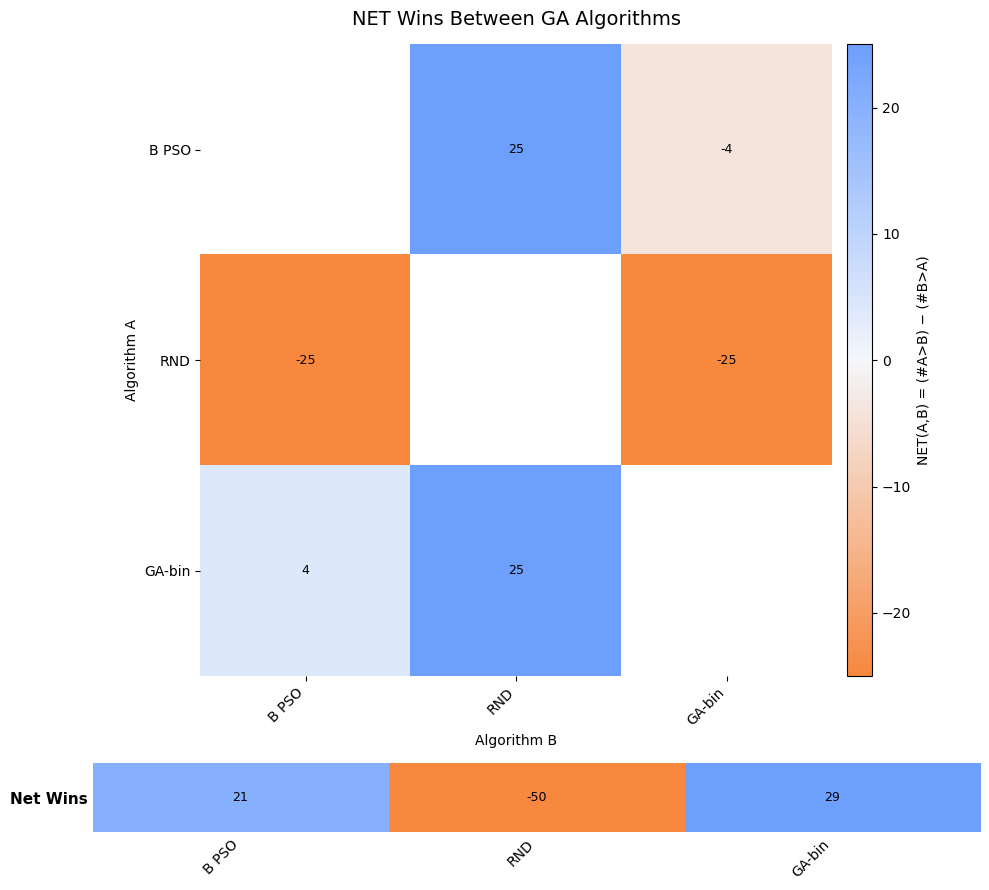

In [15]:
mat_net = build_net_from_summary(summary_holm)
plot_net_matrix_only_wins_bottom(mat_net, ALGO_ORDER, "NET Wins Between GA Algorithms")

## Best Mean Curve By Environment

To capture convergence dynamics, we analyze the Best Mean curve with confidence intervals for the various environments

In [16]:
# Make a copy of the Dataframe
df_graphics = df_analysis[["env_name", "run", "seed", "algorithm", "best_curve", "best_value"]].copy()

In [17]:
df_graphics.head(5)

,env_name,run,seed,algorithm,best_curve,best_value
0,All Inputs_perturbed,1,488498,GA-bin,"[353.55, 355.5, 355.5, 355.5, 355.8, 355.8, 35...",357.45
1,All Inputs_perturbed,17,614685,GA-bin,"[352.5, 353.1, 354.3, 354.3, 354.6, 355.2, 355...",357.45
2,All Inputs_perturbed,24,638677,GA-bin,"[351.45, 351.45, 353.1, 353.1, 354.15, 354.15,...",357.45
3,All Inputs_perturbed,2,639652,GA-bin,"[354.3, 354.3, 356.4, 356.4, 356.7, 356.7, 356...",357.45
4,All Inputs_perturbed,9,646853,GA-bin,"[352.35, 354.6, 355.95, 356.25, 356.55, 357.15...",357.45


In [18]:
import pandas as pd

def parse_list(x):
    if pd.isnull(x):
        return None
    
    if isinstance(x, list):
        return [float(i) for i in x]
    
    return [float(i) for i in eval(
        x,
        {"__builtins__": None},
        {"inf": float("inf"), "-inf": float("-inf"), "nan": float("nan")}
    )]



In [19]:

df_graphics["best_curve"] = df_graphics["best_curve"].apply(parse_list)

In [20]:
import numpy as np

df_graphics = df_graphics[
    df_graphics["best_curve"].apply(
        lambda lst: lst is not None and not any(np.isinf(i) for i in lst)
    )
]

In [21]:
def mean_curve_with_ci(curves, debug=False):
    """
    Computes the mean curve and 95% confidence interval across runs.
    Filters out invalid, empty, or malformed curves.
    """

    clean_curves = []
    for i, c in enumerate(curves):
        # Skip non-list/array items or empty ones
        if not isinstance(c, (list, np.ndarray)):
            if debug:
                print(f"⚠️ Run {i} skipped (not list/array): {type(c)} -> {c}")
            continue
        c = np.array(c, dtype=float).flatten()

        # Skip empty or NaN-only curves
        if len(c) == 0 or not np.isfinite(np.sum(c)):
            if debug:
                print(f"⚠️ Run {i} skipped (empty or invalid values): {c}")
            continue

        clean_curves.append(c)

    # If none valid, return empty arrays
    if len(clean_curves) == 0:
        if debug:
            print("❌ No valid curves in group.")
        return np.array([]), np.array([]), np.array([])

    # Truncate to the shortest length to align
    min_len = min(len(c) for c in clean_curves)
    if debug:
        print(f"✅ Using {len(clean_curves)} valid curves, truncated to length {min_len}")

    data = np.stack([c[:min_len] for c in clean_curves], axis=0)

    # Compute statistics
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0, ddof=1)
    n = data.shape[0]
    alpha = 0.05
    tcrit = t.ppf(1 - alpha/2, df=n - 1) if n > 1 else 0
    se = std / np.sqrt(n)
    ci = tcrit * se

    return mean, mean - ci, mean + ci


### Plot Settings

In [22]:

# Color Palette
ALGO_COLORS = {
    "B PSO":  "#2563eb",  # Blue
    "RND": "#7c3aed",  # purple
    "GA-bin":  "#f97316",  # orange
}



In [23]:

#Enumeration of environments
envs = sorted(df_graphics["env_name"].unique())
print("Available environments:")
for i, e in enumerate(envs):
    print(f"  {i:2d}: {e}")

Available environments:
   0: All Inputs_perturbed
   1: All Inputs_standard
   2: Assembly Tree_perturbed
   3: Assembly Tree_standard
   4: Butterfly_perturbed
   5: Butterfly_standard
   6: Dominant Input_perturbed
   7: Dominant Input_standard
   8: Explosive Expansion_perturbed
   9: Explosive Expansion_standard
  10: Interlaced Pathway_perturbed
  11: Interlaced Pathway_standard
  12: Linear All-Inputs_perturbed
  13: Linear All-Inputs_standard
  14: Linear_perturbed
  15: Linear_standard
  16: Mangrove_perturbed
  17: Mangrove_standard
  18: Mixed Test Graph_perturbed
  19: Mixed Test Graph_standard
  20: Sequential Mergers with External Inputs_perturbed
  21: Sequential Mergers with External Inputs_standard
  22: Successive Diamonds_perturbed
  23: Successive Diamonds_standard
  24: Tri-Cluster_perturbed
  25: Tri-Cluster_standard
  26: Tri-Spine Convergent_perturbed
  27: Tri-Spine Convergent_standard


In [24]:
# Set name of the environment to Plot
env_to_plot = envs[26]  # <-- Choose index of environment of interest 

In [25]:
def plot_best_curve_env(df, env_name,
                        algo_order=ALGO_ORDER,
                        color_map=ALGO_COLORS):
    subdf = df[df["env_name"] == env_name].copy()
    if subdf.empty:
        print(f"No Data for the environment: {env_name}")
        return

    fig, ax = plt.subplots(figsize=(7, 4))

    for algo in algo_order:
        df_algo = subdf[subdf["algorithm"] == algo]
        if df_algo.empty:
            continue

        curves = df_algo["best_curve"].tolist()
        mean, lower, upper = mean_curve_with_ci(curves, debug=False)
        if len(mean) == 0:
            continue

        x = np.arange(len(mean))
        color = color_map.get(algo, "black")

        ax.plot(x, mean, label=algo, color=color, linewidth=2)
        ax.fill_between(x, lower, upper, color=color, alpha=0.18, linewidth=0)

    #ax.set_title(env_name, fontsize=8)
    ax.set_xlabel("Generation", fontsize=8)
    ax.set_ylabel("Best fitness (mean ± 95% CI)", fontsize=8)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis="both", labelsize=8)
    ax.legend(frameon=False, fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()





Plotting environment: Tri-Spine Convergent_perturbed


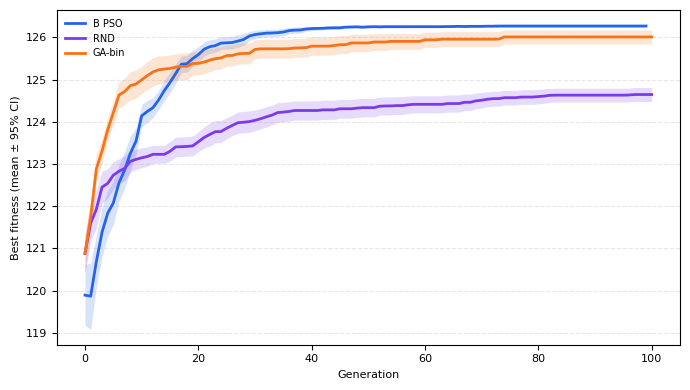

In [26]:
# Plot
print(f"Plotting environment: {env_to_plot}")
plot_best_curve_env(df_graphics, env_to_plot)


#  Number of Evaluations to Reach Best Overall Found Value 

In [27]:
# Generate Dataframe 
# ================= Helpers =================
def _to_1d_float_array(curve) -> np.ndarray:
    try:
        arr = np.array(curve, dtype=float).ravel()
    except Exception:
        import ast
        try:
            arr = np.array(ast.literal_eval(str(curve)), dtype=float).ravel()
        except Exception:
            return np.array([], dtype=float)
    arr = arr[np.isfinite(arr)]
    return arr

RTOL = 1e-6
ATOL = 1e-9



In [28]:
# ================= Base: df + env_best + thresholds =================
df = df_graphics.copy()

# max per run
df["run_max"] = df["best_curve"].apply(
    lambda c: np.nanmax(_to_1d_float_array(c)) if _to_1d_float_array(c).size else np.nan
)

# best - global 
env_best = (
    df.groupby("env_name")["run_max"]
      .max()
      .to_dict()
)

thr_90 = {e: 0.90 * env_best[e] for e in env_best}
thr_95 = {e: 0.95 * env_best[e] for e in env_best}
thr_99 = {e: 0.99 * env_best[e] for e in env_best}

# ================= Time generations =================
def _first_time_ge(curve, thr):
    """
    Primer índice t donde curve[t] >= thr.
    Devuelve 1-based (t+1). NaN si no se alcanza o thr no finito.
    """
    arr = _to_1d_float_array(curve)
    if arr.size == 0 or not np.isfinite(thr):
        return np.nan
    idx = np.where(arr >= thr)[0]
    return float(idx[0] + 1) if idx.size > 0 else np.nan

def _first_time_100(env, curve):
    """
    Primer índice t donde curve[t] alcanza el best del entorno.
    Devuelve 1-based (t+1). NaN si no se alcanza.
    """
    arr = _to_1d_float_array(curve)
    best = env_best.get(env, np.nan)
    if arr.size == 0 or not np.isfinite(best):
        return np.nan
    idx = np.where(np.isclose(arr, best, rtol=RTOL, atol=ATOL))[0]
    return float(idx[0] + 1) if idx.size > 0 else np.nan

df["t90"]  = df.apply(
    lambda r: _first_time_ge(r["best_curve"], thr_90.get(r["env_name"], np.nan)),
    axis=1
)
df["t95"]  = df.apply(
    lambda r: _first_time_ge(r["best_curve"], thr_95.get(r["env_name"], np.nan)),
    axis=1
)
df["t99"]  = df.apply(
    lambda r: _first_time_ge(r["best_curve"], thr_99.get(r["env_name"], np.nan)),
    axis=1
)
df["t100"] = df.apply(
    lambda r: _first_time_100(r["env_name"], r["best_curve"]),
    axis=1
)


# ================= Pop_size  =================
df["env_base"] = df["env_name"].str.rsplit("_", n=1).str[0].str.strip()

env_pop_size = {
    "Linear": 22,                                 # "Lineal"
    "Linear All-Inputs": 35,                      # "Linear All-inputs"
    "Assembly Tree": 32,
    "Tri-Spine Convergent": 23,
    "Sequential Mergers with External Inputs": 22,  # "Sequential Mergers"
    "Butterfly": 34,
    "Tri-Cluster": 25,
    "All Inputs": 22,                             # "All-inputs"
    "Mangrove": 40,
    "Dominant Input": 35,
    "Successive Diamonds": 29,                    # "Diamonds"
    "Interlaced Pathway": 30,
    "Explosive Expansion": 27,                    # "Explosive"
    "Mixed Test Graph": 26,                       # "All-in-One"
}

df["pop_size"] = df["env_base"].map(env_pop_size)

# ================= Generations -> nº of evals =================
# evals = tXX * pop_size
for thr in ["90", "95", "99", "100"]:
    t_col = f"t{thr}"
    e_col = f"evals_{thr}"
    df[e_col] = df[t_col] * df["pop_size"]
    df.loc[df[t_col].isna() | ~np.isfinite(df["pop_size"]), e_col] = np.nan

# ================= Final Yable =================
eval_stats_env_algo = (
    df.groupby(["env_name", "algorithm"])
      .agg(
          n_runs=("best_curve", "count"),

          # 90%
          n90=("evals_90",  lambda s: s.notna().sum()),
          evals90_mean=("evals_90", "mean"),
          evals90_std=("evals_90",  "std"),

          # 95%
          n95=("evals_95",  lambda s: s.notna().sum()),
          evals95_mean=("evals_95", "mean"),
          evals95_std=("evals_95",  "std"),

          # 99%
          n99=("evals_99",  lambda s: s.notna().sum()),
          evals99_mean=("evals_99", "mean"),
          evals99_std=("evals_99",  "std"),

          # 100% (best)
          n100=("evals_100",  lambda s: s.notna().sum()),
          evals100_mean=("evals_100", "mean"),
          evals100_std=("evals_100",  "std"),
      )
      .reset_index()
)

print(eval_stats_env_algo.to_string(index=False))

                                         env_name algorithm  n_runs  n90  evals90_mean  evals90_std  n95  evals95_mean  evals95_std  n99  evals99_mean  evals99_std  n100  evals100_mean  evals100_std
                             All Inputs_perturbed     B PSO      40   40     22.000000     0.000000   40     22.000000     0.000000   40     86.350000    56.450364    40     546.150000    180.517426
                             All Inputs_perturbed    GA-bin      40   40     22.000000     0.000000   40     22.000000     0.000000   40     45.100000    27.716329    40     526.350000    322.771297
                             All Inputs_perturbed       RND      40   40     22.000000     0.000000   40     22.000000     0.000000   40     43.450000    26.590870     1     682.000000           NaN
                              All Inputs_standard     B PSO      40   40     22.000000     0.000000   40     22.000000     0.000000   40     22.000000     0.000000    40      22.000000      0.000000
     

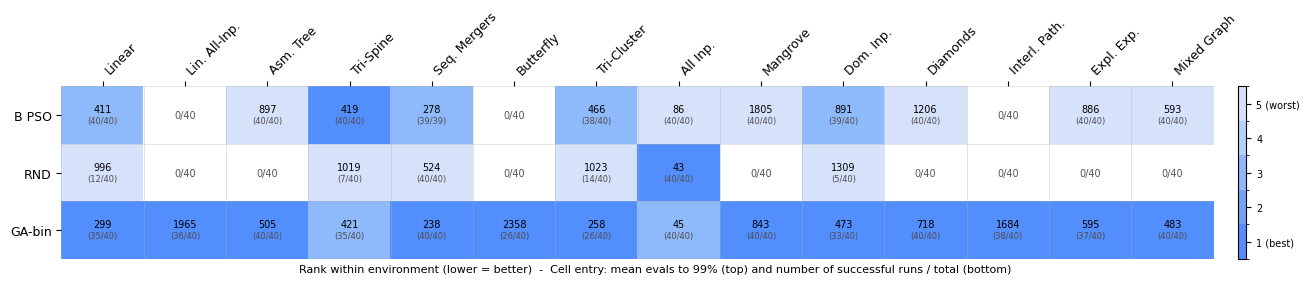

In [29]:
# ================== Config ==================

# Paleta de 5 colores (oscuro = mejor, claro = peor)
palette_5 = [
    "#528efd",  # rank 1 (best)
    "#6fa5f7",
    "#8eb9fa",
    "#b5d0fa",
    "#d6e1fa",  # rank 5 (worst)
]
cmap = ListedColormap(palette_5)

# Nombres cortos para los entornos perturbados
env_short_map = {
    "All Inputs_perturbed": "All Inp.",
    "Assembly Tree_perturbed": "Asm. Tree",
    "Butterfly_perturbed": "Butterfly",
    "Dominant Input_perturbed": "Dom. Inp.",
    "Explosive Expansion_perturbed": "Expl. Exp.",
    "Interlaced Pathway_perturbed": "Interl. Path.",
    "Linear All-Inputs_perturbed": "Lin. All-Inp.",
    "Linear_perturbed": "Linear",
    "Mangrove_perturbed": "Mangrove",
    "Mixed Test Graph_perturbed": "Mixed Graph",
    "Sequential Mergers with External Inputs_perturbed": "Seq. Mergers",
    "Successive Diamonds_perturbed": "Diamonds",
    "Tri-Cluster_perturbed": "Tri-Cluster",
    "Tri-Spine Convergent_perturbed": "Tri-Spine",
}

# ================== 1) Éxitos 99% ==================
stats = eval_stats_env_algo.copy()
stats["succ99"] = stats["n99"] / stats["n_runs"]

# ================== 2) Filtrar perturbados + algoritmos ==================
mask_pert = stats["env_name"].str.endswith("_perturbed")
stats_pert = stats.loc[mask_pert & stats["algorithm"].isin(ALGO_ORDER)].copy()

stats_pert["algorithm"] = pd.Categorical(
    stats_pert["algorithm"], categories=ALGO_ORDER, ordered=True
)
stats_pert = stats_pert.sort_values(["algorithm", "env_name"])

# ===== ORDEN DE ENTORNOS SEGÚN TU DICCIONARIO =====
env_base_order = [
    "Linear",
    "Linear All-Inputs",
    "Assembly Tree",
    "Tri-Spine Convergent",
    "Sequential Mergers with External Inputs",
    "Butterfly",
    "Tri-Cluster",
    "All Inputs",
    "Mangrove",
    "Dominant Input",
    "Successive Diamonds",
    "Interlaced Pathway",
    "Explosive Expansion",
    "Mixed Test Graph",
]

present_envs = set(stats_pert["env_name"].unique())

env_full_order = [
    f"{base}_perturbed" for base in env_base_order
    if f"{base}_perturbed" in present_envs
]

env_labels = [env_short_map.get(e, e.replace("_perturbed", "")) for e in env_full_order]
# ===================================================

# ================== 3) Matrices mean, n99 y n_runs ==================
evals99_mean_mat = (
    stats_pert
    .pivot(index="algorithm", columns="env_name", values="evals99_mean")
    .reindex(index=ALGO_ORDER, columns=env_full_order)
)

n99_mat = (
    stats_pert
    .pivot(index="algorithm", columns="env_name", values="n99")
    .reindex(index=ALGO_ORDER, columns=env_full_order)
)

n_runs_mat = (
    stats_pert
    .pivot(index="algorithm", columns="env_name", values="n_runs")
    .reindex(index=ALGO_ORDER, columns=env_full_order)
)

# ================== 4) Ranking por entorno → 5 niveles ==================
raw_ranks = evals99_mean_mat.rank(axis=0, method="min", ascending=True)

rank_group = pd.DataFrame(index=evals99_mean_mat.index,
                          columns=evals99_mean_mat.columns,
                          dtype=float)

for env in evals99_mean_mat.columns:
    col_rank = raw_ranks[env]
    max_r = col_rank.max()
    if pd.isna(max_r):
        continue
    if max_r <= 1:
        rank_group[env] = np.where(col_rank.notna(), 1, np.nan)
    else:
        denom = (max_r - 1) if max_r > 1 else 1.0
        rg = 1 + np.floor((col_rank - 1) * 5 / denom)
        rank_group[env] = rg

data_for_plot = ma.masked_invalid(rank_group.to_numpy(dtype=float))

boundaries = np.arange(0.5, 5.5 + 1, 1)
norm = BoundaryNorm(boundaries, cmap.N)

# ================== 5) Plot tipo "tablita" mejorado ==================
n_env = len(env_full_order)
n_alg = len(ALGO_ORDER)

fig, ax = plt.subplots(figsize=(0.8 * n_env + 2, 0.6 * n_alg + 1))

im = ax.imshow(data_for_plot, cmap=cmap, norm=norm, aspect="auto")

# Ejes estilo tabla
ax.set_xticks(np.arange(n_env))
ax.set_xticklabels(env_labels, rotation=45, ha="left", fontsize=9)

ax.set_yticks(np.arange(n_alg))
ax.set_yticklabels(ALGO_ORDER, fontsize=9)

# Poner los nombres de entornos arriba y quitar de abajo
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

# Cuadrícula tipo hoja de cálculo
ax.set_xticks(np.arange(-0.5, n_env, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_alg, 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.4, alpha=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# Quitar spines para look más limpio
for spine in ax.spines.values():
    spine.set_visible(False)

# Anotaciones: mean y fracción n99/n_runs
for i, alg in enumerate(evals99_mean_mat.index):
    for j, env in enumerate(evals99_mean_mat.columns):
        m = evals99_mean_mat.loc[alg, env]
        n_succ = n99_mat.loc[alg, env]
        n_total = n_runs_mat.loc[alg, env]

        if pd.isna(n_total):
            continue

        if not pd.isna(m) and not pd.isna(n_succ) and n_succ > 0:
            eval_str = f"{m:.0f}"
            frac_str = f"({int(n_succ)}/{int(n_total)})"

            ax.text(
                j, i - 0.1,
                eval_str,
                ha="center", va="center",
                fontsize=7, color="black"
            )

            ax.text(
                j, i + 0.1,
                frac_str,
                ha="center", va="center",
                fontsize=6, color="#504E4E"
            )
        else:
            fail_text = f"0/{int(n_total)}"
            ax.text(
                j, i,
                fail_text,
                ha="center", va="center",
                fontsize=7, color="#555555"
            )

fig.text(
    0.5, 0.0001,
    "Rank within environment (lower = better)  -  Cell entry: mean evals to 99% (top) and number of successful runs / total (bottom)",
    ha="center", va="bottom", fontsize=8
)


# Colorbar con niveles de ranking
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, ticks=[1, 2, 3, 4, 5])
cbar.ax.set_yticklabels(["1 (best)", "2", "3", "4", "5 (worst)"])
cbar.ax.tick_params(labelsize=7)



plt.tight_layout()
plt.savefig("heatmap_perturbed_1.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()